<a href="https://colab.research.google.com/github/yuvashree1708/ANTI-BIOFILM-TARGETING/blob/main/Antibiofilm_Target.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import mean_squared_error
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import jaccard_score
from sklearn.metrics import RocCurveDisplay
from sklearn import metrics

In [3]:
df = pd.read_excel("/content/TargIDe_Database_Descriptors.xlsx")
df.head()

,BiofilmDBID,Structure [idcode],Molecule Name,Molecule ID,ActiveID,m,Value,Unit,Type,Ligand Efficiency,...,cLogS,MATS4p,GATS3m,GATS6m,GATS2e,GATS4p,HybRatio,MDEO-12,MLFER_A,R_TpiPCTPC
0,1,dcLLB@STyImYWeVf@B@cH,T_P20582_PqsD_A_107682,T_P20582_PqsD_A_107682,107682,=,30.0,%,Inhibition,0.00,...,-1.703,-0.087342,1.146208,1.327104,0.465981,1.044591,0.000000,0.0,1.134,5.552246
1,2,dklD@@QIevUuujh@H@@,T_P20582_PqsD_A_1476007,T_P20582_PqsD_A_1476007,1476007,<,10.0,%,Inhibition,0.00,...,-2.336,-0.156266,1.167451,0.986088,0.783925,1.102958,0.363636,0.5,0.003,3.560799
2,3,dknD@CADfWYWWVj`@`@@,T_P20582_PqsD_A_1476010,T_P20582_PqsD_A_1476010,1476010,<,10.0,%,Inhibition,0.00,...,-2.068,-0.153129,1.140002,0.976549,0.790474,1.107460,0.300000,0.5,0.250,3.560799
3,4,fhia`BH@PjDh{HihhdiXdaR|EhBB`@BGD@,T_P20582_PqsD_A_1574897,T_P20582_PqsD_A_1574897,1574897,=,1000.0,nM,IC50,0.48,...,-3.220,-0.144897,0.812773,1.136901,0.547021,1.082718,0.076923,0.0,0.348,6.699013
4,5,fhia`BH@PjDh{HihhdiXdaR|EhBB`@BGD@,T_P20582_PqsD_A_1574897,T_P20582_PqsD_A_1574897,1574897,=,3200.0,nM,IC50,0.44,...,-3.220,-0.144897,0.812773,1.136901,0.547021,1.082718,0.076923,0.0,0.348,6.699013


In [4]:
##Define features (X) as the list of features determined as most important
##.values attribute converts pandas DataFrame into a NumPy array - necessary for distance calculation
X = df[['MATS4p','R_TpiPCTPC','cLogS','GATS3m','MDEO-12','HybRatio','GATS4p','MLFER_A','GATS6m','GATS2e']].values
##Define features (X) as combinations of n features of the 10 most important ones

In [5]:
comb=['MATS4p','R_TpiPCTPC','cLogS','GATS3m','MDEO-12','HybRatio','GATS4p','MLFER_A','GATS6m','GATS2e']
comb_list=list(comb)

In [6]:
X = df[comb_list].values

In [7]:
Y = df['Target ID'].values

In [8]:
#Dataset division in Train and Test set
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.3, random_state=4)

In [9]:
#TRAIN THE MODEL
XGBoost = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=0).fit(X_train, Y_train)
#Predict Answers With Trained Model and Most Accurate K for train and test set
predict_train = XGBoost.predict(X_train)
predict_test = XGBoost.predict(X_test)
#EVALUATE MODEL PREDICTION ABILITY
##F1_Score: weighted average of the precision and recall, where an F1 score reaches its best value at 1 and worst score at 0. The relative co
###F1_Score for train set
f1_xb_train = f1_score(Y_train, predict_train, average='weighted')

In [10]:
###F1_Score for test set
f1_xb_test = f1_score(Y_test, predict_test, average='weighted')
##Jaccard Similarity Coefficient: size of the intersection divided by the size of the union of two label sets
###Jaccard Coefficient for train set
jaccard_xb_train = jaccard_score(Y_train, predict_train,average='weighted')
###Jaccard Coefficient for test set
jaccard_xb_test = jaccard_score(Y_test, predict_test,average='weighted')
##Calculate Accuracy Score:
###Accuracy Score for train set
accuracy_xb_train = accuracy_score(Y_train, predict_train, normalize=True)

In [11]:
###Accuracy Score for test set
accuracy_xb_test = accuracy_score(Y_test, predict_test, normalize=True)
##Calculate Precision Score:The precision is the ratio tp / (tp + fp) where tp is the number of true positives and fp the number of false pos
#The best value is 1 and the worst value is 0.
###Precision score for train set
precision_xb_train = precision_score(Y_train, predict_train, average='weighted', zero_division=0)
###Precision score for test set
precision_xb_test = precision_score(Y_test, predict_test, average='weighted', zero_division=0)
##Calculate Recall Score: recall is the ratio tp / (tp + fn) where tp is the number of true positives and fn the number of false negatives. T
#The best value is 1 and the worst value is 0.
###Recall score for train set:
recall_xb_train = metrics.recall_score(Y_train, predict_train, average='weighted', zero_division=0)
###Recall score for test set:
recall_xb_test = metrics.recall_score(Y_test, predict_test, average='weighted', zero_division=0)

In [13]:
#XG BOOST WITH UNKNOWN SAMPLES FOR TESTING
print("XG_BOOST FOREST FOR PREDICTION")
#Open input file
df = pd.read_excel("/content/Compund database.xlsx")
df.head()
##Define features (X) as the 4 best features
#X = df[['HybRatio','cLogS','GATS4p','GATS6m']].values
##Define features (X) as the 5 best features
#X = df[['MATS4p','cLogS','HybRatio','MLFER_A','GATS4p']].values
##Define features (X) as the list of 10 most relevant features
X = df[['MATS4p','R_TpiPCTPC','cLogS','GATS3m','MDEO-12','HybRatio','GATS4p','MLFER_A','GATS6m','GATS2e']].values
##Define Target Value y:
Y = df['Target ID'].values
#Dataset division in Train and Test set
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.3, random_state=4)
#TRAIN THE MODEL
XGBoost = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=0).fit(X_train, Y_train)
#Predic Answers With Trained Model and Most Accurate K for train and test set
predict_train = XGBoost.predict(X_train)
predict_test = XGBoost.predict(X_test)

XG_BOOST FOREST FOR PREDICTION


In [14]:
##Predict on Unknown sample input file
test_samples = pd.read_excel("/content/Compund database.xlsx")
columns_test = test_samples[['MATS4p','R_TpiPCTPC','cLogS','GATS3m','MDEO-12','HybRatio','GATS4p','MLFER_A','GATS6m','GATS2e']].values #.a
print(columns_test[0])
print(columns_test[1])
print(columns_test[2])
pred_newsamples=XGBoost.predict(columns_test[0:14])
print(pred_newsamples)

[-0.08734221  5.55224609 -1.703       1.14620847  0.          0.
  1.04459132  1.134       1.32710371  0.46598119]
[-1.56265535e-01  3.56079932e+00 -2.33600000e+00  1.16745051e+00
  5.00000000e-01  3.63636364e-01  1.10295809e+00  3.00000000e-03
  9.86088277e-01  7.83925065e-01]
[-0.15312904  3.56079932 -2.068       1.14000212  0.5         0.3
  1.10745961  0.25        0.97654948  0.79047384]
[1 1 1 1 1 1 1 1 1 1 1 1 1 7]


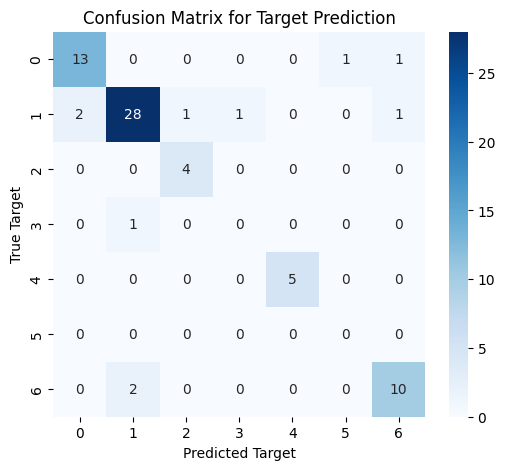

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, predict_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Target")
plt.ylabel("True Target")
plt.title("Confusion Matrix for Target Prediction")
plt.show()

In [16]:
results = pd.DataFrame({
    "Predicted_Target": pred_newsamples
})

results.to_csv("predicted_targets.csv", index=False)